# Notebook 1 — Data Understanding & Preprocessing

This notebook covers a complete data preprocessing pipeline for the **Loan Approval Dataset**.  
It includes loading, understanding, cleaning, encoding, dataset creation, and feature scaling — preparing the data for classification (Notebook 2) and regression (Notebook 3).

---
## Part A — Load Data

We begin by importing the necessary Python libraries and loading the dataset from a CSV file.  
The libraries used include **pandas** for data manipulation, **numpy** for numerical operations, **matplotlib** and **seaborn** for visualisation, and **scikit-learn** for preprocessing utilities.

In [1]:
# Import the pandas library for data manipulation and analysis
import pandas as pd

# Import numpy for numerical computations
import numpy as np

# Import matplotlib for creating static visualisations
import matplotlib.pyplot as plt

# Import seaborn for enhanced statistical visualisations
import seaborn as sns

# Import LabelEncoder for converting categorical labels to integers
from sklearn.preprocessing import LabelEncoder

# Import StandardScaler for feature normalisation (mean=0, std=1)
from sklearn.preprocessing import StandardScaler

# Set the seaborn visual style for all plots
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# Set the default figure size for matplotlib plots
plt.rcParams["figure.figsize"] = (10, 6)

### Step 1 — Load the CSV Dataset

The dataset is loaded using pandas.read_csv(). We display the first 5 rows to verify the data has been loaded correctly and to get an initial view of the features.

In [2]:
# Define the file path to the CSV dataset
file_path = "loan_approval_data.csv"

# Load the dataset into a pandas DataFrame
df = pd.read_csv(file_path)

# Print a header for clarity in the output
print("=== First 5 Rows of the Dataset ===")

# Display the first 5 rows of the DataFrame
df.head()

=== First 5 Rows of the Dataset ===


,id,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,35437,21.0,12000,OWN,0,EDUCATION,15000,6.99,0.12,N,4,0,-2426900
1,53756,21.0,13200,OWN,2,EDUCATION,25000,16.77,0.19,Y,3,0,-111739
2,42205,23.0,9600,RENT,5,MEDICAL,30000,12.42,0.31,N,3,0,-89000
3,19180,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0,35000
4,28072,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0,35000


---
## Part B — Data Understanding

In this section, we perform an initial exploration of the dataset to understand its structure, dimensions, data types, and summary statistics.

### Step 3 — Dataset Overview

We use df.info() to inspect column names, non-null counts, and data types. We use df.describe().transpose() to review summary statistics. We also print df.dtypes.

In [3]:
# Print a header for the dataset information section
print("=== Dataset Information ===")

# Display structural information about the DataFrame
print(df.info())

# Print a separator for readability
print("\n" + "="*60)

# Print a header for the summary statistics section
print("=== Summary Statistics (Transposed) ===")

# Display descriptive statistics transposed for better readability
print(df.describe().transpose())

# Print a separator for readability
print("\n" + "="*60)

# Print a header for the data types section
print("=== Column Data Types ===")

# Display the data type of each column
print(df.dtypes)

=== Dataset Information ===
<class 'pandas.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       58645 non-null  int64  
 1   age                      58639 non-null  float64
 2   income                   58645 non-null  int64  
 3   home_ownership           58645 non-null  str    
 4   emplyment_length         58645 non-null  int64  
 5   loan_intent              58645 non-null  str    
 6   loan_amount              58645 non-null  int64  
 7   loan_interest_rate       58634 non-null  float64
 8   loan_income_ratio        58645 non-null  float64
 9   payment_default_on_file  58640 non-null  str    
 10  credit_history_length    58645 non-null  int64  
 11  loan_approval_status     58645 non-null  int64  
 12  max_allowed_loan         58645 non-null  int64  
dtypes: float64(3), int64(7), str(3)
memory usage: 5.8 MB
None



### Steps 4 & 5 — Separate Numerical and Categorical Columns

We separate columns into numerical (using np.number) and categorical (using object or string dtype) lists.

In [4]:
# Select all columns with numerical data types
numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()

# Select all columns with categorical (object/string) data types
categorical_columns = df.select_dtypes(include=["object", "string"]).columns.tolist()

# Print a header for the numerical columns list
print("=== Numerical Columns ===")

# Display the list of numerical columns
print(numerical_columns)

# Print a header for the categorical columns list
print("\n=== Categorical Columns ===")

# Display the list of categorical columns
print(categorical_columns)

=== Numerical Columns ===
['id', 'age', 'income', 'emplyment_length', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'credit_history_length', 'loan_approval_status', 'max_allowed_loan']

=== Categorical Columns ===
['home_ownership', 'loan_intent', 'payment_default_on_file']


---
## Part C — Data Issues Detection

Before cleaning the data, we identify key issues: missing values, duplicate rows, and irrelevant ID columns.

### Step 6 — Missing Values

We check for missing values across all columns and display only those columns that contain at least one missing value.

In [5]:
# Calculate the number of missing values per column
missing_values = df.isnull().sum()

# Filter to show only columns with missing values greater than zero
missing_only = missing_values[missing_values > 0]

# Print a header for the missing values report
print("=== Missing Values (Columns with Missing Data Only) ===")

# Check if any columns have missing values
if len(missing_only) > 0:
    # Display the columns and their missing value counts
    print(missing_only)
else:
    # Confirm that no missing values were found
    print("No missing values found in the dataset.")

=== Missing Values (Columns with Missing Data Only) ===
age                         6
loan_interest_rate         11
payment_default_on_file     5
dtype: int64


### Step 7 — Duplicate Rows

We check for any duplicate rows in the dataset.

In [6]:
# Count the total number of duplicate rows in the DataFrame
duplicate_count = df.duplicated().sum()

# Print a header for the duplicates report
print("=== Duplicate Rows ===")

# Display the number of duplicate rows found
print(f"Number of duplicate rows: {duplicate_count}")

=== Duplicate Rows ===
Number of duplicate rows: 0


### Step 8 — Identify ID Columns

ID columns are identifiers that carry no predictive value. We identify them here for removal.

In [7]:
# Identify columns that are named id or end with _id (case-insensitive)
id_columns = [col for col in df.columns if col.lower() == "id" or col.lower().endswith("_id")]

# Print a header for the ID columns detection
print("=== ID Columns Detected ===")

# Display the list of detected ID columns
print(id_columns if id_columns else "No ID columns found.")

=== ID Columns Detected ===
['id']


### Step 9 — Summary of All Detected Issues

We consolidate and print all detected data quality issues in one place.

In [8]:
# Print a combined summary of all detected data issues
print("=" * 60)
print("DATA ISSUES SUMMARY")
print("=" * 60)

# Report missing values
print(f"\n1. Missing values found in {len(missing_only)} column(s):")

# Display the missing value columns if any exist
if len(missing_only) > 0:
    # Print each column with its missing count
    for col_name, count in missing_only.items():
        print(f"   - {col_name}: {count} missing")
else:
    # Confirm no missing values
    print("   None")

# Report duplicate rows
print(f"\n2. Duplicate rows: {duplicate_count}")

# Report ID columns
print(f"\n3. ID columns to drop: {id_columns}")

# Print closing separator
print("=" * 60)

DATA ISSUES SUMMARY

1. Missing values found in 3 column(s):
   - age: 6 missing
   - loan_interest_rate: 11 missing
   - payment_default_on_file: 5 missing

2. Duplicate rows: 0

3. ID columns to drop: ['id']


---
## Part D — Data Cleaning

In this section we address the issues detected above:
- Missing numerical values → filled with the median
- Missing categorical values → filled with the mode
- Duplicate rows → removed
- ID columns → dropped

### Step 10 — Handle Missing Values

Numerical columns are imputed using the median (robust to outliers). Categorical columns are imputed using the mode (most frequent value).

In [9]:
# Loop through each numerical column to fill missing values
for col in numerical_columns:
    # Check if the current column has any missing values
    if df[col].isnull().any():
        # Calculate the median of the column
        median_val = df[col].median()
        # Fill missing values with the median
        df[col] = df[col].fillna(median_val)
        # Print confirmation of imputation
        print(f"Filled {col} missing values with median: {median_val}")

# Loop through each categorical column to fill missing values
for col in categorical_columns:
    # Check if the current column has any missing values
    if df[col].isnull().any():
        # Calculate the mode (most frequent value) of the column
        mode_val = df[col].mode()[0]
        # Fill missing values with the mode
        df[col] = df[col].fillna(mode_val)
        # Print confirmation of imputation
        print(f"Filled {col} missing values with mode: {mode_val}")

# Print confirmation that missing value handling is complete
print("\nMissing value imputation complete.")

Filled age missing values with median: 26.0
Filled loan_interest_rate missing values with median: 10.75
Filled payment_default_on_file missing values with mode: N

Missing value imputation complete.


### Step 11 — Remove Duplicates

If duplicate rows exist, we drop them to avoid training bias.

In [10]:
# Store the shape before removing duplicates for comparison
shape_before = df.shape[0]

# Drop duplicate rows from the DataFrame
df = df.drop_duplicates()

# Store the shape after removing duplicates
shape_after = df.shape[0]

# Calculate the number of rows removed
rows_removed = shape_before - shape_after

# Print the result of duplicate removal
print(f"=== Duplicate Removal ===")
print(f"Rows before: {shape_before}")
print(f"Rows after:  {shape_after}")
print(f"Duplicates removed: {rows_removed}")

=== Duplicate Removal ===
Rows before: 58645
Rows after:  58645
Duplicates removed: 0


### Step 12 — Drop ID Columns

ID columns are removed as they are unique identifiers with no predictive value.

In [11]:
# Print which ID columns will be dropped
print("=== Dropping ID Columns ===")
print(f"Columns to drop: {id_columns}")

# Drop the ID columns if any were detected
if id_columns:
    # Remove the ID columns from the DataFrame
    df = df.drop(columns=id_columns)
    # Confirm successful removal
    print("ID columns dropped successfully.")
else:
    # Confirm that no ID columns needed removal
    print("No ID columns to drop.")

# Update the numerical columns list after dropping ID columns
numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()

# Update the categorical columns list after dropping ID columns
categorical_columns = df.select_dtypes(include=["object", "string"]).columns.tolist()

# Print updated column lists
print(f"\nUpdated numerical columns: {numerical_columns}")
print(f"Updated categorical columns: {categorical_columns}")

=== Dropping ID Columns ===
Columns to drop: ['id']
ID columns dropped successfully.

Updated numerical columns: ['age', 'income', 'emplyment_length', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'credit_history_length', 'loan_approval_status', 'max_allowed_loan']
Updated categorical columns: ['home_ownership', 'loan_intent', 'payment_default_on_file']


### Step 13 — Re-check Missing Values After Cleaning

We verify that no missing values remain after the cleaning steps.

In [12]:
# Calculate missing values after cleaning
missing_after = df.isnull().sum()

# Filter to show only columns with remaining missing values
missing_remaining = missing_after[missing_after > 0]

# Print a header for the verification check
print("=== Missing Values After Cleaning ===")

# Check if any missing values remain
if len(missing_remaining) > 0:
    # Display any remaining missing values
    print(missing_remaining)
else:
    # Confirm the dataset is clean
    print("No missing values remaining. Dataset is clean.")

=== Missing Values After Cleaning ===
No missing values remaining. Dataset is clean.


---
## Part E — Encoding Categorical Variables

Machine learning models require numerical input. We use LabelEncoder from scikit-learn to convert each categorical column into integer-encoded values.

### Steps 14 & 15 — Apply LabelEncoder to All Categorical Columns

We loop through each categorical column, apply LabelEncoder, and print the encoded column names.

In [13]:
# Create a dictionary to store encoders for each categorical column
encoder_dict = {}

# Loop through each categorical column to apply label encoding
for col in categorical_columns:
    # Create a new LabelEncoder instance for this column
    encoder_dict[col] = LabelEncoder()
    # Fit the encoder on column values and transform them to integers
    df[col] = encoder_dict[col].fit_transform(df[col].astype(str))

# Print a header for the encoding confirmation
print("=== Categorical Variables Encoded ===")

# Print the list of columns that were encoded
print(f"Encoded columns: {categorical_columns}")

# Display the first 5 rows to verify encoding
print("\n=== Encoded Data Preview ===")
df.head()

=== Categorical Variables Encoded ===
Encoded columns: ['home_ownership', 'loan_intent', 'payment_default_on_file']

=== Encoded Data Preview ===


,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,21.0,12000,2,0,1,15000,6.99,0.12,0,4,0,-2426900
1,21.0,13200,2,2,1,25000,16.77,0.19,1,3,0,-111739
2,23.0,9600,3,5,3,30000,12.42,0.31,0,3,0,-89000
3,40.0,182004,3,3,1,35000,8.00,0.19,0,11,0,35000
4,40.0,90000,0,3,2,35000,12.42,0.39,0,14,0,35000


---
## Part F — Target Variable Selection

We define the target variables for the two modelling tasks:
- Classification target → loan_approval_status (0 = Approved, 1 = Rejected)
- Regression target → max_allowed_loan (maximum loan amount for approved applications)

### Steps 16 & 17 — Define and Print Target Variables

We explicitly set the classification and regression target column names.

In [14]:
# Define the classification target column name
classification_target = "loan_approval_status"

# Define the regression target column name (maximum loan amount)
regression_target = "max_allowed_loan"

# Print a header for the target variable definitions
print("=== Target Variables Defined ===")

# Display the classification target
print(f"Classification target: {classification_target}")

# Display the regression target
print(f"Regression target:     {regression_target}")

=== Target Variables Defined ===
Classification target: loan_approval_status
Regression target:     max_allowed_loan


---
## Part G — Create Classification Dataset

We create the feature matrix (X_classification) and target vector (y_classification) for the classification task.

### Steps 18 & 19 — Create X and y for Classification

We drop the target column from the features and print the shapes of both arrays.

In [15]:
# Create the feature matrix by dropping the classification target column
X_classification = df.drop(columns=[classification_target])

# Create the target vector for classification
y_classification = df[classification_target]

# Print a header for the classification dataset shapes
print("=== Classification Dataset Created ===")

# Print the shape of the feature matrix
print(f"X_classification shape: {X_classification.shape}")

# Print the shape of the target vector
print(f"y_classification shape: {y_classification.shape}")

# Print a header for the target value distribution
print("\n=== Target Value Counts ===")

# Display the count of each class in the target variable
print(y_classification.value_counts().sort_index())

=== Classification Dataset Created ===
X_classification shape: (58645, 11)
y_classification shape: (58645,)

=== Target Value Counts ===
loan_approval_status
0    50295
1     8350
Name: count, dtype: int64


### Step 20 — Target Interpretation

We explicitly state the meaning of each class label for clarity.

In [16]:
# Print the interpretation of target class labels
print("=== Target Label Interpretation ===")

# Print the meaning of class 0
print("0 = Approved")

# Print the meaning of class 1
print("1 = Rejected")

=== Target Label Interpretation ===
0 = Approved
1 = Rejected


### Step 21 — Countplot of Classification Target

We create a professional bar chart showing the distribution of loan approval statuses.

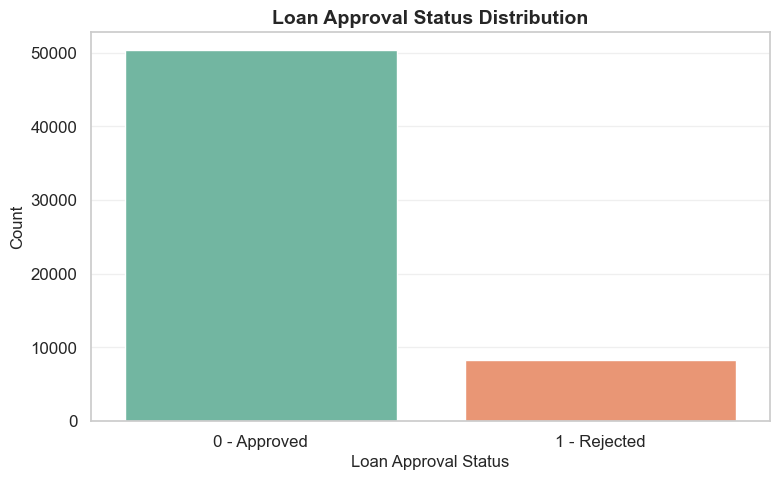

Total Applications: 58645
Approved: 50295 (85.76%)
Rejected: 8350 (14.24%)


In [17]:
# Create a new figure with specified dimensions
plt.figure(figsize=(8, 5))

# Create a countplot of the classification target with custom colours
ax = sns.countplot(x=y_classification, hue=y_classification, palette="Set2", legend=False)

# Set the plot title with bold formatting
plt.title("Loan Approval Status Distribution", fontsize=14, fontweight="bold")

# Set the x-axis label
plt.xlabel("Loan Approval Status", fontsize=12)

# Set the y-axis label
plt.ylabel("Count", fontsize=12)

# Set the x-axis tick positions first
ax.set_xticks([0, 1])

# Replace x-axis tick labels with descriptive names
ax.set_xticklabels(["0 - Approved", "1 - Rejected"])

# Add light gridlines on the y-axis only
plt.grid(axis="y", alpha=0.3)

# Adjust layout to prevent label clipping
plt.tight_layout()

# Display the plot
plt.show()

# Print summary statistics below the plot
print(f"Total Applications: {len(y_classification)}")
print(f"Approved: {(y_classification == 0).sum()} ({(y_classification == 0).sum() / len(y_classification) * 100:.2f}%)")
print(f"Rejected: {(y_classification == 1).sum()} ({(y_classification == 1).sum() / len(y_classification) * 100:.2f}%)")

---
## Part H — Create Regression Dataset

The regression dataset includes only approved loans (where loan_approval_status == 0). The target variable is max_allowed_loan.

### Steps 22, 23 & 24 — Filter Approved Loans and Create Regression Dataset

We filter the DataFrame to include only approved loan applications, then create the feature matrix and target vector for regression.

In [18]:
# Create a boolean mask to filter only approved loans (status == 0)
approved_mask = df[classification_target] == 0

# Filter the DataFrame to include only approved loans
approved_loans = df[approved_mask].copy()

# Create the regression feature matrix (drop both target columns)
X_regression = approved_loans.drop(columns=[regression_target, classification_target])

# Create the regression target vector
y_regression = approved_loans[regression_target]

# Print a header for the regression dataset
print("=== Regression Dataset Created (Approved Loans Only) ===")

# Print the shape of the regression feature matrix
print(f"X_regression shape: {X_regression.shape}")

# Print the shape of the regression target vector
print(f"y_regression shape: {y_regression.shape}")

# Print summary statistics of the regression target
print("\n=== Regression Target Statistics ===")
print(y_regression.describe())

=== Regression Dataset Created (Approved Loans Only) ===
X_regression shape: (50295, 10)
y_regression shape: (50295,)

=== Regression Target Statistics ===
count    5.029500e+04
mean     8.133543e+04
std      5.919723e+04
min     -2.426900e+06
25%      4.909150e+04
50%      6.942700e+04
75%      9.898900e+04
max      2.638778e+06
Name: max_allowed_loan, dtype: float64


---
## Part I — Feature Scaling

We apply StandardScaler to normalise all features to have mean = 0 and standard deviation = 1. This is important for algorithms sensitive to feature scales.

### Steps 25, 26 & 27 — Scale Features and Convert Back to DataFrame

After scaling, we convert the NumPy arrays back to pandas DataFrames to preserve column names for downstream use.

In [19]:
# Create a StandardScaler instance for classification features
scaler_classification = StandardScaler()

# Create a StandardScaler instance for regression features
scaler_regression = StandardScaler()

# Fit and transform the classification feature matrix
X_classification_scaled = scaler_classification.fit_transform(X_classification)

# Fit and transform the regression feature matrix
X_regression_scaled = scaler_regression.fit_transform(X_regression)

# IMPORTANT FIX: Convert the scaled classification array back to a DataFrame with column names
X_classification_scaled = pd.DataFrame(
    X_classification_scaled,
    columns=X_classification.columns
)

# IMPORTANT FIX: Convert the scaled regression array back to a DataFrame with column names
X_regression_scaled = pd.DataFrame(
    X_regression_scaled,
    columns=X_regression.columns
)

# Print a header for the scaling confirmation
print("=== Feature Scaling Complete ===")

# Print the shape of the scaled classification features
print(f"X_classification_scaled shape: {X_classification_scaled.shape}")

# Print the type to verify it is a DataFrame
print(f"X_classification_scaled type:  {type(X_classification_scaled)}")

# Print the shape of the scaled regression features
print(f"\nX_regression_scaled shape:    {X_regression_scaled.shape}")

# Print the type to verify it is a DataFrame
print(f"X_regression_scaled type:     {type(X_regression_scaled)}")

=== Feature Scaling Complete ===
X_classification_scaled shape: (58645, 11)
X_classification_scaled type:  <class 'pandas.DataFrame'>

X_regression_scaled shape:    (50295, 10)
X_regression_scaled type:     <class 'pandas.DataFrame'>


---
## Part J — Final Fixes

We ensure that the classification target variable is of integer type for compatibility with scikit-learn classifiers.

### Steps 28 & 29 — Cast Target to Integer and Verify Types

We explicitly cast y_classification to int and print the types of all final variables.

In [20]:
# Cast the classification target to integer type
y_classification = y_classification.astype(int)

# Print a header for the type verification
print("=== Final Variable Types ===")

# Print the type of the scaled classification features
print(f"X_classification_scaled: {type(X_classification_scaled)}")

# Print the dtype of the classification target
print(f"y_classification dtype:  {y_classification.dtype}")

# Print the type of the scaled regression features
print(f"X_regression_scaled:     {type(X_regression_scaled)}")

# Print the dtype of the regression target
print(f"y_regression dtype:      {y_regression.dtype}")

=== Final Variable Types ===
X_classification_scaled: <class 'pandas.DataFrame'>
y_classification dtype:  int64
X_regression_scaled:     <class 'pandas.DataFrame'>
y_regression dtype:      int64


---
## Part K — Final Summary

We print a complete summary of all prepared datasets and confirm that all variables are ready for Notebook 2 and Notebook 3.

### Step 30 — Print All Dataset Shapes and Confirmation

This final cell provides a consolidated view of all output variables and their shapes.

In [21]:
# Print the opening banner
print("\n" + "=" * 60)
print("PREPROCESSING COMPLETE - FINAL SUMMARY")
print("=" * 60)

# Print a header for the classification dataset summary
print("\n=== Classification Dataset ===")

# Print the shape of the unscaled classification features
print(f"X_classification shape:        {X_classification.shape}")

# Print the shape of the scaled classification features
print(f"X_classification_scaled shape: {X_classification_scaled.shape}")

# Print the shape of the classification target
print(f"y_classification shape:        {y_classification.shape}")

# Print a header for the regression dataset summary
print("\n=== Regression Dataset ===")

# Print the shape of the unscaled regression features
print(f"X_regression shape:            {X_regression.shape}")

# Print the shape of the scaled regression features
print(f"X_regression_scaled shape:     {X_regression_scaled.shape}")

# Print the shape of the regression target
print(f"y_regression shape:            {y_regression.shape}")

# Print a header for the confirmation section
print("\n=== Variables Ready for Model Training ===")

# Confirm each output variable is ready
print("X_classification_scaled - Classification features (scaled)")
print("y_classification        - Classification target (0=Approved, 1=Rejected)")
print("X_regression_scaled     - Regression features from approved loans (scaled)")
print("y_regression            - Regression target (max_allowed_loan)")

# Print the closing statement
print("\nAll variables are ready for Notebook 2 and Notebook 3.")
print("=" * 60)


PREPROCESSING COMPLETE - FINAL SUMMARY

=== Classification Dataset ===
X_classification shape:        (58645, 11)
X_classification_scaled shape: (58645, 11)
y_classification shape:        (58645,)

=== Regression Dataset ===
X_regression shape:            (50295, 10)
X_regression_scaled shape:     (50295, 10)
y_regression shape:            (50295,)

=== Variables Ready for Model Training ===
X_classification_scaled - Classification features (scaled)
y_classification        - Classification target (0=Approved, 1=Rejected)
X_regression_scaled     - Regression features from approved loans (scaled)
y_regression            - Regression target (max_allowed_loan)

All variables are ready for Notebook 2 and Notebook 3.
